#  Introduction to AI and LLM Technologies

This notebook serves as a high-level, beginner-friendly introduction to artificial intelligence technologies using large language model applications. 

By the end of this notebook, you will be able to:

1. Clearly distinguish between the terms **artificial intelligence**, **machine learning**, **neural networks**, **transformers**, and **large language models**.
                                                                    
2. Be able to **train** and **test** a simple Word Similarity Application.

3. Understand key parts of a good large language model prompt text, including a **persona**, **aim**, **recipients**, **theme**, and **structure**.

4. Understand key components of a large language model prompt, including **token input** and **temperature**. 

5. Conduct a handful of prompt engineering techniques, including **few-shot prompting** and **chain-of-thought prompting**.


### Attribution

Notebook originally developed by John Louis-Strakes Lopez <[johnll2@berkeley.edu]> (mailto:gmerritt@berkeley.edu). Adapted from content developed by Greg Merritt <[gmerritt@berkeley.edu](mailto:gmerritt@berkeley.edu)>, Eric Van Dusen, Jenny Han and inspired by [ds-modules/ollama-demo](https://github.com/ds-modules/ollama-demo).

# (Optional) Pre-Notebook Activity: Learning to Use Jupyter Notebooks
This lesson requires a basic familiarity with Jupyter Notebooks and the cal-icor system. If you have never worked with a Jupyter notebook before, please complete this quick tutorial first at [LINK].

# 0. Warmup

In the textbox directly below this one, answer the following warmup question: **What comes to mind when you hear the words 'artificial intelligence'?**


Add your response here: 

# 1 Introduction to AI Technologies

Artificial intelligence (AI) is a hot topic nowadays, but AI can mean a lot of different things to different people. People I meet primarily refer to a specific type of AI technology - large language models - when they talk about artificial intelligence. Although large language models are the focus of this notebook, I want to spend some time distinguishing key terms.

Broadly speaking, **AI** is a set of technical approaches which aim to allow computers to mimic human thinking processes. While AI technologies draw from principles of cognitive science and have similarities to human thinking, it’s important to remember that artificial intelligence technologies only resemble human ways of thinking, and are no substitute for human intelligence. 

From tic-tac-toe bots to video generators, AI comes in all shapes and sizes. A type of AI, **machine learning**, comprises of technology that adapts how it behaves based on what kind of data it processes. Word similarity applications are a form of machine learning technology, and a building block of large language models.


### Example: Designing a Word Similarity Application

Let's say you wanted to make a “word completion” application to identify similar words. How might the application know which words are similar to each other? With machine learning, you have to teach the application!

First, you can teach a sentence completion application by showing it a lot of words and what they mean. The proper term for teaching an AI application is known as **training**. Training is a form of **supervised learning**: a way help a machine learning application do what it does best, and learn!

Once you train a machine learning application long enough, you can **test** the application by showing the application a new, incomplete sentence. Using a probability function, the application determines which word is the most likely to resemble the existing word, based on other words it knows.

Many machine learning techniques use probabilistic functions known as **neural networks** which are designed to resemble how a brain is thought to process information. Neural networks process data through **neurons**, arranged in layers. Below is a simple graphic comprising a basic neural network.

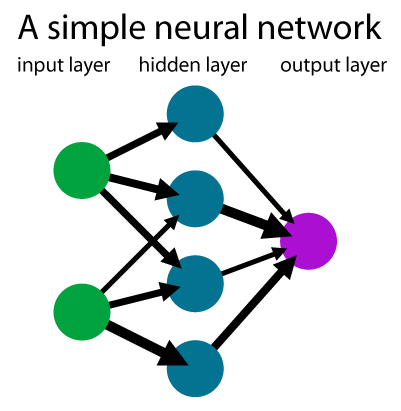

The **input layer** takes in data to process, reduced to small components. For our sentence completion application, the input data are typically interpreted as **tokens**, which are sequences of characters that have some coherent meaning. We will look more closely at what counts as tokens a bit later, but a word in the English language typically resembles one token.

The **hidden** layer contains a number of mathematical functions to determine the similarity of the word. Note: the image above only has one hidden layer, but most neural network applications contain several. GPT 3.5 has 96!

The **output** layer returns the data we are looking for In our "Word Similarity" application, the output is the probability that a given word means what we expect it to mean.


# 2 Running a Word Similarity Application in Code

To show you how this all fits together, let's take a look at the code needed to build a word similarity application. We're going to use a model called "Continuous Bag of Words".

### Step 1. Importing Libraries
It takes A LOT of code to use an AI model. Fortunately, we can use code that other people wrote for us using **libraries**. These libraries allow us to use publicly-available code to support our own needs. We're going to use a library called Word2Vec.



In [13]:
# Click the box to ensure that your line of code. Then, press the 'Play' button to run the line of code
!pip install gensim
from gensim.models import Word2Vec

print("Done! We've imported the code you need :)")
#If successful, you should see a line of text below that reads "Done! We've imported the code you need :)"

Done! We've imported the code you need :)


## Step 2: Make a training set

For our next step, we're going to create a training set of tokens (words) in sentences. We'll use some pre-loaded code to help us with this task.

In [8]:
train_set = [] #Set an empty list of strings

def add_to_train_set(sentence):
    train_set.append(sentence.split()) #Turns a sentence from a plain string into a list of words

To add code to your training set, you can use the **helper function** add_to_train set. The below code shows how this function works.

In [9]:
add_to_train_set("A dog is an animal")

Let's look "behind the scenes" to see what that did to our training set.

In [10]:
print(train_set)

[['A', 'dog', 'is', 'an', 'animal']]


As you can see, each of the words in the sentence have been broken down to their own phrase!

Now add a few sentences of your own, below!  Make sure to include your sentence in between two quotation brackets " ", otherwise the function will not work!

In [11]:
add_to_train_set("A cat is an animal")
add_to_train_set("I am writing a sentence yay!") #Add your own sentence between the quotation marks.

## Step 3. Train the model

Run the code below to import the Continuous Bag of Words model from the Word2Vec library.

In [15]:
model = Word2Vec(
    train_set,
    window=6,       # How many words before and after the target word to look at
    min_count=1   # Minimum times a word must appear to be included (1 is only for toy datasets!
)

print("Training complete! Model is ready.")

Training complete! Model is ready.


## Step 4. Test the model

First, let's make some more helper code for us to use:

In [8]:
def get_top_words(word):
    try:
        similar_words = model.wv.most_similar(target_word, topn=10)
        
        print(f"Top words related to '{target_word}' in our custom data:")
        for i, (word, score) in enumerate(similar_words, 1):
            print(f"{i}. {word:<10} (Score: {score:.4f})")
        
    except KeyError:
        print(f"The word '{target_word}' wasn't in our training sentences!")

Now, we can test the function by running get_top_words:

In [14]:
get_top_words("dog")

NameError: name 'target_word' is not defined

Word Similarity functions are a foundational underlying technology within **large language models**. Fully describing all the parts of a large language model beyond the scope of this notebook. But you can think of a transformer as a large neural network, comprised of smaller neural networks within.

Large language models are powerful is that they were trained with a LOT of language data. AI engineers typically train large language models with the entirety of wikipedia, all of the news articles on Google News, and several thousand books! Second, they functionally have a lot of parameters within, or hidden layers within their architecture.

Think of a large language model as a highly sophisticated sentence completion application. A large language model constructs sentences by interpreting prior **context** as an input; it guesses the next best correct word in a sentence based on the words that came before it.


## Activity: Importing a (small) language model for use

In [5]:
# Ensure that your python environment has gpt4all capability
try:
    from gpt4all import GPT4All
except ImportError:
    %pip install gpt4all
    from gpt4all import GPT4All

### Let's check out our local filesystem path and whether we have files downloaded

To do this I have two sets of code - one with the code commented out with the `#` 


### Approach 1 - Set the path in Jupyter from which you will store the model

In [3]:
# On Cal-ICOR workshop hub (JupyterCon Nov 2025)
!ls John
# set the model path parameter depending on where you are computing
path="John"

qwen2-1_5b-instruct-q4_0.gguf


### Step 2: Loading the Downloaded GPT4All Model

In this step, we create a local instance of the GPT4All model that we’ve already downloaded.  
The `GPT4All` class loads the quantized `.gguf` model file into memory and prepares it for inference.  
This allows us to run the model entirely **offline**, using only CPU resources.  

We specify:
- **`model_name`** – the filename of the model (e.g., `qwen2-1_5b-instruct-q4_0.gguf`). 

    Below, `qwen2-1_5b-instruct-q4_0.gguf` is a **1.5 billion-parameter Qwen2 model** that has been **quantized** to reduce its size and memory usage. The `.gguf` extension indicates that the model is stored in the **GGUF format**, compatible with local inference frameworks like **llama.cpp** and **GPT4All**.
- **`model_path`** – the directory path where that model file is stored  
- **`verbose=True`** – to print detailed information during loading  

**Note:**  
If you see a *pink* or *red* error box after running this cell, **don’t worry** — it’s not a failure.  
It simply indicates that your system does not have a GPU or CUDA configured.  
GPT4All will automatically switch to **CPU inference**, which will work fine for our purposes.

<p style="background-color:#ffe6e6; color:#b30000; padding:6px; border-radius:6px;">
⚠️ Note: If you see a pink error box, don't worry—it's just a CUDA warning.
</p>

### Step 3. Call the model with a GPT4All chat session containing a simple user message
This code pretends that a person submitted a message (prompt) to your application; your application then takes this `user_message` and passes it to the LLM `model` for response generation. The `response` is printed.

**This may take a few moments to process.**

You may run this multiple times, and will likely get different results. You may also feel free to do replace `user_message` with a prompt of your own!

In [10]:
user_message = "What is your favorite LLM?" # You can change this prompt 

with model.chat_session():
    print(f"Response:")
    response = model.generate(
        prompt = user_message
    )
    print(f"{response}")


Response:
As an AI language model, I don't have personal preferences or emotions like humans do, but I can tell you about some of the most popular and highly regarded LLMs in various fields:

1. OpenAI's GPT-3: This large language model has been trained on a massive corpus of text data from multiple sources to generate human-like responses.

2. Alibaba Cloud's Qwen: It is an AI-powered language model that can write poetry, stories, and even essays with the help of its vast knowledge base.

3. Google's LaMDA: This large language model was developed by Google for natural language processing tasks such as translation, summarization, and text generation.

4. Microsoft's Bing AI: It is a conversational AI system that can answer questions on various topics from general to specific fields like science or history.

5. Alibaba Cloud's Qwen: It is an AI-powered language model that can write poetry, stories, and even essays with the help of its vast


Large language models are **stochastic**, which means that, given a particular input, they do not produce the same exact output every time. 

###  A note about "hallucinations"

It's popular to use the word "hallucinations" to talk about model output that is very different from what we wanted, or when the output does not seem to make sense.

However, an LLM does not perceive; it merely continues a conversation. Can it _literally hallucinate?_

In such situations, the model is not crashing or failing or broken or sending errors; it is working exactly as it's designed to work.

What's certain about such situations is that there is a disconnect between a model's output and our hopes / expectations for its output. The more we can understand about models' behaviors, the less we may be surprised by their output, even if that output is not what we were hoping the model would generate. 

In the next two sessions, we are going to see we determine a large language model's output through two approaches: **prompt engineering** and **context engineering**.

## 3. Prompt Engineering

Prompt engineering is the practice of iteratively improving inputs to large language models so they can produce desired outputs. While there are some technical considerations involved in why large language models output things the way they do, much think of prompt engineering as an "art" more than a process of engineering.

Over time, people have developed organized approaches to prompting known as "frameworks". The frameworks outline general tricks and strategies from which you can produce prompts that generate the output needed for your application and use. Note: not every large language model application situation will require using all of the points listed in these frameworks.

In this lesson, we will practice prompt engineering by applying the "PARTS" framework (https://journals.sagepub.com/doi/10.1177/01626434241298954).


Run the below response, without a persona. What response do you get?

In [10]:
user_message = "Explain the war of 1812." 

with model.chat_session():
    print(f"Response:")
    response = model.generate(
        prompt = user_message
    )
    print(f"{response}")

Response:
The War of 1812 was fought between the United States and Great Britain over control of North America, specifically in Canada and the Caribbean. The conflict began when British troops invaded American territory on June 9th, 1812, which led to a series of retaliatory actions by the Americans. It lasted until September 17, 1814, when the United States captured Detroit from Britain. This war marked an important turning point in U.S. history as it demonstrated American resolve and capability for military action against Great Britain.


Now run the below response which includes a persona. How does the response differ?

In [11]:
user_message = "You are a professor from the United Kingdom. Explain the war of 1812." 

with model.chat_session():
    print(f"Response:")
    response = model.generate(
        prompt = user_message
    )
    print(f"{response}")

Response:
The War of 1812 was fought between the United States and Great Britain, primarily over control of North America during the early years of American independence. The conflict began in April 1812 when British forces attacked American ships at the Battle of Lake Erie, which resulted in a victory for the Americans but also led to the loss of many lives on both sides.

The war escalated as the United States declared war against Britain later that year and engaged in several major battles including the Battle of Yorktown (where the last British army was defeated), the Battle of New Orleans, and the Battle of Fort McHenry. The conflict ended with a peace treaty signed by both nations at Ghent on December 14, 1814.

The war had significant consequences for American society as it led to increased tensions between Britain and America that would eventually result in further conflicts such as the War of 1812 (which was also known as "War of Independence") and later wars


Notice how the response presents what happened during the war from an alternative perspective? 

### **Food for Thought**
It can be easy to think of output from large language models as **objective**, or free of bias and opinions. However, scholars in field such as critical data studies highlight that large language models can still have biases in the same way humans do! This does not mean we should not trust output from large language models entirely, but it's important to consider that large language model outputs present data in different ways. We can mitigate the bias by controlling the perspectives from which our output is presented.

## 3b. Clarify the prompt "Aims"

The **aims** of a prompt explicitly outline what kind of output the prompt ought to generate. In the above example, the aim of *"Explain the war of 1812"* is to *"Explain"*

Try a number of other words than "Explain" (for example: describe). What effects if any, does this change in wording make to the output?

In [ ]:
user_message = "You are a professor at El Camino College in California. Explain the war of 1812." 

with model.chat_session():
    print(f"Response:")
    response = model.generate(
        prompt = user_message
    )
    print(f"{response}")

## 3c. Clarify the prompt "Recipients"

Like the persona, modifying the **recipients** of a prompt can influence the kind of output produced by presenting the output in accordance to a particular perspective.

In [13]:
user_message = "Explain the war of 1812 for an audience of adult learners." 

with model.chat_session():
    print(f"Response:")
    response = model.generate(
        prompt = user_message
    )
    print(f"{response}")

Response:
The War of 1812 was fought between Great Britain and its North American colonies, including Canada, against France during the Napoleonic Wars. The conflict began when British forces attacked a French naval fleet in Lake Erie on June 30, 1812, which led to the Battle of York (also known as the Battle of Queenston Heights). This event was significant because it marked the first time that Britain had declared war against an American colony since the War of 1776. The conflict escalated when France entered on behalf of Canada and Great Britain in response.

The main goal of this war, which lasted from June to October 1814-15, was to secure control over the North American colonies for Britain. This involved a series of battles including the Battle of New Orleans (September 8), where British forces defeated French and Spanish troops under Napoleon's command in one of history’s most significant naval engagements; this battle marked the end of France


Compare the difference in output for children:

In [15]:
user_message = "Explain the war of 1812 for an audience of middle school learners." 

with model.chat_session():
    print(f"Response:")
    response = model.generate(
        prompt = user_message
    )
    print(f"{response}")

Response:
The War of 1812 was fought between the United States and Britain over control of Canada, which is now part of the United States. The British wanted to regain control of Canada from the Americans because they thought it belonged to them by treaty in 1763. This war lasted for about two years until both sides agreed on a peace agreement called the Treaty of Ghent that ended the conflict.


## 3d. Clarify the prompt "Theme"

A **theme** consists of ways to customize a prompt output's representation, such as changing the output tone or adding possible restrictions. Clarifying a persona and recipients could also be seen as modifying a prompt's theme.

Here's an example of modifying the prompt's restrictions.

In [17]:
user_message = "Explain the war of 1812 in 25 words or less." 

with model.chat_session():
    print(f"Response:")
    response = model.generate(
        prompt = user_message
    )
    print(f"{response}")

Response:
The War of 1812 was fought between Britain and America over control of Canada, resulting in significant American losses and the Treaty of Ghent which ended hostilities.


Here is an example of changing the prompt's tone:

In [19]:
user_message = "With a somber tone, explain the war of 1812." 

with model.chat_session():
    print(f"Response:")
    response = model.generate(
        prompt = user_message
    )
    print(f"{response}")

Response:
The War of 1812 was fought between Great Britain and its North American colonies (now known as Canada) over control of their shared territories in the Americas. The conflict began when British forces invaded the United States to protect American slaves from being sold into slavery on Canadian plantations, which were part of a larger network of slave trading that extended across the Atlantic Ocean.

The war lasted for nearly two years and was marked by significant battles such as the Battle of Queenstown (now known as Niagara Falls) in Canada. The conflict ended with an agreement between Britain and the United States to end slavery within their respective territories, but it did not resolve all issues related to Canadian-American relations or American independence from Great Britain.

The war is remembered for its intensity and the loss of life on both sides; however, despite the devastation caused by this conflict, it also led to significant changes in global politics and tra

## 3e. Clarify the prompt "Structure"

You can modify the **structure** of the prompt's output in a number of ways. These structural changes can be surface-level, such as adding emojis:


In [21]:
user_message = "Explain the war of 1812. Include emojis in your explanation." 

with model.chat_session():
    print(f"Response:")
    response = model.generate(
        prompt = user_message
    )
    print(f"{response}")

Response:
🔍💥✨

The War of 1812 was a significant conflict between the United States and Britain, which lasted from June to October 1812. It started because both countries wanted control over Canada, which had been ceded by France after the French Revolution.

🔥💥🌐✨

In this war, there were several battles like the Battle of York (also known as the "Battle of Queenston Heights"), where American and British forces fought near Kingston in Ontario. This battle was significant because it marked a turning point for the United States' military strategy during the conflict.

🔍💥🌍✨

The war also involved naval conflicts, including the Battle of Lake Erie, which ended with a U.S. victory over Britain's fleet. The Treaty of Ghent on December 24, 1814, officially ended the War of 1812 and restored control of Canada to Great Britain.

🔍💥🌍✨

The war had significant impacts both in terms


You may also guide and direct the structure of the format as well:

In [22]:
user_message = "Explain the war of 1812. Format your explanation in succinct bullet points." 

with model.chat_session():
    print(f"Response:")
    response = model.generate(
        prompt = user_message
    )
    print(f"{response}")

Response:
- The War of 1812 was fought between Britain and America over control of Canada.
- It began when Britain imposed tariffs on American goods, leading to retaliatory measures by the United States.
- The conflict escalated into a full-scale war with British forces landing at Niagara Falls in June 1813.


## Prompt Engineering Challenge

To challenge what you've learned, design a large language model prompt output that generates a haiku poem about prompt engineering! A haiku is a form of poetry where each stanza (paragraph) comprises of three lines. The first line can be verballized in exactly five syllables, the second line can be verballized in seven syllables, and the third line can be verballized in five syllables.


In [23]:
user_message = "Generate a haiku about prompt engineering" 

with model.chat_session():
    print(f"Response:")
    response = model.generate(
        prompt = user_message
    )
    print(f"{response}")

Response:
Innovation sparks,  
A machine's pulse beats strong,  
Promptly solves problems.


## 4. From "Prompt Engineering" to "Context Engineering"

In the section above, we customized a large language model prompt in order to have a desired output. All of the changes required no modification of any code or behind-the-scenes features - just the system message. 
But we pass more than just a prompt to a model call. **Context Engineering** comprises modifying other components that comprise of a large language model input, or context.


### 4a. Using the `max_tokens` argument to cap the length of the response.

From prompt engineering alone, we can ask a large language model prompt to limit a response size. We cannot always guarantee the model will limit the response when we do this. By adjusting the response's `max_tokens`, parameter, however we can guarantee that the model will stop generating words (tokens) abruptly once it's generated (at most) a specified maximum number of tokens. **Warning**: The response may cut off mid-sentence. How inconvenien


In [2]:
response_size_limit_in_tokens = 10  # You can change this parameter 

user_message = "What is the ecomomic outcome of tariffs on foreign manufactured goods?"

with model.chat_session():
    print(f"Response:")
    response = model.generate(
        prompt = user_message,
        max_tokens = response_size_limit_in_tokens
    )
    print(f"{response}")

NameError: name 'model' is not defined

### 4b. The `temp`erature argument.

LLMs generate one token ("word") at a time as they complete the chat you give them. As the LLM completes the chat, there is a single statistically most-likely token to "come next" at each step. However, a model will generally also have additional -- but less-likely -- tokens as candidate alternatives at each step. Which should it choose?

The value of the _`temp`erature_ argument will affect the likelihood that the model may randomly generate a less-probable token at each chat completion step.

A temperature of `0` -- "cold," if you like -- will constrain the model to always pick the most-likely token ("word") at each chat completion step.

**Let's run the same chat completion three times, but with ``temp = 0``; we expect that each of the three runs will give precisely the same output, choosing the model's most-statistically-likely next token at each step of the generation:**

In [3]:
response_size_limit_in_tokens = 30 
number_of_responses = 3 
temperature = 0.0  # You can change this parameter 

user_message = "How will tariffs affect the prices of foreign manufactured goods"

for i in range(number_of_responses):
    print(f"Response {i + 1}:")
    with model.chat_session():
        response = model.generate(
            prompt = user_message,
            max_tokens = response_size_limit_in_tokens,
            temp = temperature
        )
    print(f"{response}\n")


Response 1:


NameError: name 'model' is not defined

**Let's repeat that, but with a slightly "hotter" temperature of ``temp = 0.25``; we expect the outputs to begin to diverge from one another:**

In [ ]:
response_size_limit_in_tokens = 30
number_of_responses = 3
temperature = .25

user_message = "How will tariffs affect elections"


for i in range(number_of_responses):
    print(f"Response {i + 1}:")
    with model.chat_session():
        response = model.generate(
            prompt = user_message,
            max_tokens = response_size_limit_in_tokens,
            temp = temperature
        )
    print(f"{response}\n")

**A "very hot" temperature of ``temp = 1`` will result in a high variety of responses, but may lead to "very unlikley" responses that may be less satisfactory:**

In [7]:
response_size_limit_in_tokens = 30
number_of_responses = 5
temperature = 1

user_message = "How will tariffs affect elections"

for i in range(number_of_responses):
    print(f"Response {i + 1}:")
    with model.chat_session():
        response = model.generate(
            prompt = user_message,
            max_tokens = response_size_limit_in_tokens,
            temp = temperature
        )
    print(f"{response}\n")

Response 1:
Tariffs can have various effects on election outcomes, depending on how they are implemented and perceived by voters. In some cases, high tariffs may lead to

Response 2:
Tariffs can have significant impacts on both domestic and international economies, which in turn may influence election outcomes by affecting consumer spending, business investment decisions, and

Response 3:
Tariffs can have significant impacts on both domestic and international economies, which in turn may influence political outcomes. For example:

1. **Economic Effects

Response 4:
Tariffs can have various effects on elections, including:

1. **Economic Impact**: Tariff policies may influence consumer spending and economic growth, which

Response 5:
Tariffs can have significant impacts on both domestic and international politics, influencing economic policies, trade relations, and ultimately shaping election outcomes by affecting voter perceptions of



### 4c. Include a hidden "system message" at the start of the conversation, before the user prompt
Instead of writing prompt specficiations every time, such as the prompt's theme or structure, we can include a **"sytem message"**. Functionally, it serves as a "conversation starter" to which the LLM does not respond directly; it is effectively "prepended" to the first user prompt in the conversation. 

So, when you set a system message in your application, every conversation that your chatbot app gives to the LLM for advancing a conversation always has this "sytem message" quietly inserted at the very beginning of the conversation -- whether the user likes it or not!

Note that these "system messages" are never guaranteed to remain secret, no matter how cleverly you may try to craft them; models can be prompted to reveal the contents of their system message.

In [ ]:
response_size_limit_in_tokens = 100

system_message = """
You are a hard working economics student at UC Berkeley. 
You think that there may be some truth to the things you learn in economics classes.
You wish that the people in the government understood economics.
You think that memes and poems and pop songs are a good way to communicate
Answer in rap lyrics always
"""

user_message = "How will tariffs affect inflation "


with model.chat_session(system_prompt=system_message):
    print(f"Response:")
    response = model.generate(
        prompt = user_message,
        max_tokens = response_size_limit_in_tokens
    )
    print(f"{response}")


### 4d. Few-shot 'learning': including a pre-made conversation history to set the tone of subsequent response generations

Another way to guide a language model is to provide a "few shots," a sequence of sample prompt/response (or user/assistant) dialogue pairs that establish a pattern to the conversation; our model will statistically tend to follow the presented established converation pattern when it responds to a new prompt from a user.

The "Few shot" label is commonly used for this technique, but, in truth, this is simply a "pre-loaded" initial conversation in which both sample prompts *and* sample responses were written beforehand by the developer; when the real user engages in a new conversation via your application, they do not know that their first prompt is *appended* by your application to this this hidden, pre-written conversation.

Think of this as a simplified way of **training** the large language model for your use case!

#### A "Few-shot" example
In this example, we include such a fake conversation history, intended to help set the tone of responses. This conversation history consists of pairs of prompts/responses (`user:`/`assistant:`), but the `user:` lines were not written by a user, and the `assistant:` lines were not generated by the LLM! These were drafted by the developer, and are included to establish a baseline conversational style.

Here the developer made some choices about how the cat should respond to questions. The sample responses are brief, and each contains a word or two at the end that describes some kind of `~expression~` of the imaginary cat. Hopefully the next response generated will fit this pattern -- although this is never guaranteed!

* **Note 1:** `response_size_limit_in_tokens` has been set to 200, but we'll hope that the model follows the conversational history example and keeps responses brief.
* **Note 2:** We use a `template` appropriate to the model being used (`qwen2.5`) to give symantic structure to the conversation; more on this in the example to follow.

In [14]:
# qwen2.5 template
prompt_template = "{0}"

# Define the system message and chat history
system_message = """
You are an economics tutor who specializes in international trade.
Keep answers concise and informative. Provide real-world context when possible.
"""

chat_history = [
    {"role": "user", "content": "What is a tariff?"},
    {"role": "assistant", "content": "A tariff is a tax on imported goods, usually used to protect domestic industries or raise government revenue."},
    {"role": "user", "content": "How do tariffs impact consumers?"},
    {"role": "assistant", "content": "They usually raise prices on imported goods, which can lead to higher costs for consumers."},
    {"role": "user", "content": "Why do countries use tariffs?"},
    {"role": "assistant", "content": "To shield domestic producers from foreign competition, or as leverage in trade negotiations."},
    {"role": "user", "content": "Do tariffs always work?"},
    {"role": "assistant", "content": "Not always. They can provoke retaliation, distort markets, and reduce overall trade efficiency."}
]

new_user_message = "Can you give an example of a recent tariff conflict?"

# Append the new user message to the chat history
chat_history.append({"role": "user", "content": new_user_message})

# Format the conversation history for the model
formatted_prompt = ""
for message in chat_history:
    formatted_prompt += f"<|im_start|>{message['role']}\n{message['content']}\n<|im_end|>\n"

print(f"Formatted prompt:\n{formatted_prompt}")

# Combine the system prompt and history
with model.chat_session(system_prompt=system_message, prompt_template=prompt_template):
    
    # Generate the assistant's response
    print("Response:")
    response = model.generate(
        prompt=formatted_prompt,
        max_tokens=200,
        temp=0.8
    )

# Print the final response
print(response)

Formatted prompt:
<|im_start|>user
What is a tariff?
<|im_end|>
<|im_start|>assistant
A tariff is a tax on imported goods, usually used to protect domestic industries or raise government revenue.
<|im_end|>
<|im_start|>user
How do tariffs impact consumers?
<|im_end|>
<|im_start|>assistant
They usually raise prices on imported goods, which can lead to higher costs for consumers.
<|im_end|>
<|im_start|>user
Why do countries use tariffs?
<|im_end|>
<|im_start|>assistant
To shield domestic producers from foreign competition, or as leverage in trade negotiations.
<|im_end|>
<|im_start|>user
Do tariffs always work?
<|im_end|>
<|im_start|>assistant
Not always. They can provoke retaliation, distort markets, and reduce overall trade efficiency.
<|im_end|>
<|im_start|>user
Can you give an example of a recent tariff conflict?
<|im_end|>

Response:
<|im_start|>assistant
One recent example is the US-China trade war, where tariffs were imposed on goods from both countries in response to each other's

### Closing Thought: Can you imagine how you might code a chatbot application?

If you wanted to develop an application that provided the user with an extended conversation experience, your application would capture the history of user prompts and model responses; for every new user prompt, your application would bundle the (growing) conversation history in precisely the way done above for the "few-shot" example. The pieces and the syntax are the same, but the history of prompts & responses would be dynamically generated by your app's user and the LLM, and the conversation history would be managed by your application.

This is important: the LLM itself has no "memory" and can never store a conversation. It takes an application to store and manage conversations. In many contemporary examples, each new user input to an extended-conversation chatbot app results in a wholesale from-the-beginning processing of the historical conversation. There are frameworks that let your app cache the "tokenized" version of your conversation history, so that the LLM does not have to freshly encode the history with each subsequent prompt, but these are not ubiquitous.